# Momentum & Mean-Reversion Algorithmic Strategies

One of the most well known algorithmic stratregies of all time is the momentum strategy. Esentially, you bet that winners will keep on winning, and that losers will keep on losing.

One of the most common implementations is having a lookback period of a year. You rank each stock in your universe by returns, and long/short the deciles. The strategy rebalances monthly, so each month, it does the same ranking for the 12 previous months, and if needed adjusts position sizes.

However, I believe we can take this a bit further. Today, we are going to introduce you to Simple Moving Averages (SMA), Exponential Moving Averages (EMA), and Relative Strength Index (RSI), and Bollinger Bands.

First, let's import the Python libraries we need. Run the code below to do so.

In [1]:
# If needed, run %pip install yfinance pandas in a separate cell.
import yfinance as yf
import pandas as pd
import matplotlib as plt

Now, let's define our S&P 500 universe using the ticker list below.

In [2]:
sp500_tickers = ['MMM', 'AOS', 'ABT', 'ABBV', 'ACN', 'ADBE', 'AMD', 'AES', 'AFL', 'A', 'APD', 'ABNB', 'AKAM', 'ALB', 'ARE', 'ALGN', 'ALLE', 'LNT', 'ALL', 'GOOGL', 'GOOG', 'MO', 'AMZN', 'AMCR', 'AEE', 'AEP', 'AXP', 'AIG', 'AMT', 'AWK', 'AMP', 'AME', 'AMGN', 'APH', 'ADI', 'AON', 'APA', 'APO', 'AAPL', 'AMAT', 'APP', 'APTV', 'ACGL', 'ADM', 'ARES', 'ANET', 'AJG', 'AIZ', 'T', 'ATO', 'ADSK', 'ADP', 'AZO', 'AVY', 'AXON', 'BKR', 'BALL', 'BAC', 'BAX', 'BDX', 'BRK-B', 'BBY', 'TECH', 'BIIB', 'BLK', 'BX', 'XYZ', 'BE', 'BNY', 'BA', 'BKNG', 'BSX', 'BMY', 'AVGO', 'BR', 'BRO', 'BF-B', 'BG', 'BXP', 'CHRW', 'CDNS', 'CPT', 'COF', 'CAH', 'CCL', 'CARR', 'CVNA', 'CASY', 'CAT', 'CBOE', 'CBRE', 'CDW', 'COR', 'CNC', 'CNP', 'CF', 'CRL', 'SCHW', 'CHTR', 'CVX', 'CMG', 'CB', 'CHD', 'CIEN', 'CI', 'CINF', 'CTAS', 'CSCO', 'C', 'CFG', 'CLX', 'CME', 'CMS', 'KO', 'CTSH', 'COHR', 'COIN', 'CL', 'CMCSA', 'FIX', 'COP', 'ED', 'STZ', 'CEG', 'COO', 'CPRT', 'GLW', 'CPAY', 'CTVA', 'CSGP', 'COST', 'CRH', 'CRWD', 'CCI', 'CSX', 'CMI', 'CVS', 'DHR', 'DRI', 'DDOG', 'DVA', 'DECK', 'DE', 'DELL', 'DAL', 'DVN', 'DXCM', 'FANG', 'DLR', 'DG', 'DLTR', 'D', 'DPZ', 'DASH', 'DOV', 'DOW', 'DHI', 'DTE', 'DUK', 'DD', 'ETN', 'EBAY', 'ECHO', 'ECL', 'EIX', 'EW', 'ELV', 'EME', 'EMR', 'ETR', 'EOG', 'EQT', 'EFX', 'EQIX', 'ERIE', 'ESS', 'EL', 'EG', 'EVRG', 'P', 'ES', 'EXC', 'EXE', 'EXPE', 'EXPD', 'EXR', 'XOM', 'FFIV', 'FDS', 'FICO', 'FAST', 'FRT', 'FDX', 'FDXF', 'FERG', 'FIS', 'FITB', 'FSLR', 'FE', 'FISV', 'FLEX', 'F', 'FTNT', 'FTV', 'FOXA', 'FOX', 'BEN', 'FCX', 'GRMN', 'IT', 'GE', 'GEHC', 'GEV', 'GEN', 'GNRC', 'GD', 'GIS', 'GM', 'GPC', 'GILD', 'GPN', 'GL', 'GDDY', 'GS', 'HAL', 'HIG', 'HAS', 'HCA', 'DOC', 'HSIC', 'HSY', 'HPE', 'HLT', 'HD', 'HONA', 'HON', 'HRL', 'HST', 'HWM', 'HPQ', 'HUBB', 'HUM', 'HBAN', 'HII', 'IBM', 'IEX', 'IDXX', 'ITW', 'ILMN', 'INCY', 'IR', 'PODD', 'INTC', 'IBKR', 'ICE', 'IFF', 'IP', 'INTU', 'ISRG', 'IVZ', 'INVH', 'IQV', 'IRM', 'JBHT', 'JBL', 'JKHY', 'J', 'JNJ', 'JCI', 'JPM', 'KVUE', 'KDP', 'KEY', 'KEYS', 'KMB', 'KIM', 'KMI', 'KKR', 'KLAC', 'KHC', 'KR', 'LHX', 'LH', 'LRCX', 'LVS', 'LDOS', 'LEN', 'LII', 'LLY', 'LIN', 'LYV', 'LMT', 'L', 'LOW', 'LULU', 'LITE', 'LYB', 'MTB', 'MPC', 'MAR', 'MRSH', 'MLM', 'MRVL', 'MAS', 'MA', 'MKC', 'MCD', 'MCK', 'MDT', 'MRK', 'META', 'MET', 'MTD', 'MGM', 'MCHP', 'MU', 'MSFT', 'MAA', 'MRNA', 'MDLZ', 'MPWR', 'MNST', 'MCO', 'MS', 'MOS', 'MSI', 'MSCI', 'NDAQ', 'NTAP', 'NFLX', 'NEM', 'NWSA', 'NWS', 'NEE', 'NKE', 'NI', 'NDSN', 'NSC', 'NTRS', 'NOC', 'NCLH', 'NRG', 'NUE', 'NVDA', 'NVR', 'NXPI', 'ORLY', 'OXY', 'ODFL', 'OMC', 'ON', 'OKE', 'ORCL', 'OTIS', 'PCAR', 'PKG', 'PLTR', 'PANW', 'PSKY', 'PH', 'PAYX', 'PYPL', 'PNR', 'PEP', 'PFE', 'PCG', 'PM', 'PSX', 'PNW', 'PNC', 'PPG', 'PPL', 'PFG', 'PG', 'PGR', 'PLD', 'PRU', 'PEG', 'PTC', 'PSA', 'PHM', 'PWR', 'QCOM', 'DGX', 'Q', 'RL', 'RJF', 'RDDT', 'RTX', 'O', 'REG', 'REGN', 'RF', 'RSG', 'RMD', 'RVTY', 'HOOD', 'ROK', 'ROL', 'ROP', 'ROST', 'RCL', 'SPGI', 'CRM', 'SNDK', 'SBAC', 'SLB', 'STX', 'SRE', 'NOW', 'SHW', 'SPG', 'SWKS', 'SJM', 'SW', 'SNA', 'SOLV', 'SO', 'LUV', 'SWK', 'SBUX', 'STT', 'STLD', 'STE', 'SYK', 'SMCI', 'SYF', 'SNPS', 'SYY', 'TMUS', 'TROW', 'TTWO', 'TPR', 'TRGP', 'TGT', 'TEL', 'TDY', 'TER', 'TSLA', 'TXN', 'TPL', 'TXT', 'TMO', 'TJX', 'TKO', 'TSCO', 'TT', 'TDG', 'TRV', 'TRMB', 'TFC', 'TYL', 'TSN', 'USB', 'UBER', 'UDR', 'ULTA', 'UNP', 'UAL', 'UPS', 'URI', 'UNH', 'UHS', 'VLO', 'VEEV', 'VTR', 'VLTO', 'VRSN', 'VRSK', 'VZ', 'VRTX', 'VRT', 'VTRS', 'VICI', 'V', 'VST', 'VMRK', 'VMC', 'WRB', 'GWW', 'WAB', 'WMT', 'DIS', 'WBD', 'WM', 'WAT', 'WEC', 'WFC', 'WELL', 'WST', 'WDC', 'WY', 'WSM', 'WMB', 'WTW', 'WDAY', 'WYNN', 'XEL', 'XYL', 'YUM', 'ZBRA', 'ZBH', 'ZTS']

Next, let's download the daily prices. Our strategy will start on **October 1, 2025**, but we will load data from **October 1, 2024** so we have a year of history to calculate our indicators.

We will use adjusted closing prices, which account for stock splits and dividends. We also download SPY to compare our strategy with the market later.

The end date is exclusive, so using today's date keeps today's unfinished daily bar out of the data.

In [3]:
strategy_start = "2025-10-01"
today = pd.Timestamp.now(tz="Europe/Lisbon").strftime("%Y-%m-%d")

data = yf.download(
    sp500_tickers + ["SPY"],
    start="2024-10-01",
    end=today,
    auto_adjust=True,
    progress=False,
)

prices = data["Close"][sp500_tickers]
spy_prices = data["Close"]["SPY"]

$WBD: possibly delisted; no price data found  (1d 2024-10-01 -> 2026-10-08)



1 Failed download:


['WBD']: possibly delisted; no price data found  (1d 2024-10-01 -> 2026-10-08)


Let's look at the first few rows to see what we downloaded. Each row is a date and each column is a stock. We will use this price table to calculate the SMA, EMA, RSI, and Bollinger Bands.

Some stocks have shorter histories, so you may see `NaN`, which means a price is missing. Leave these values as they are for now.

In [4]:
prices.head()

Ticker,MMM,AOS,ABT,ABBV,ACN,ADBE,AMD,AES,AFL,A,...,WMB,WTW,WDAY,WYNN,XEL,XYL,YUM,ZBRA,ZBH,ZTS
Date,,,,,,,,,,,,,,,,,,,,,
2024-10-01,131.947861,85.324402,108.901588,184.437469,338.640472,502.799988,159.750000,18.202547,108.209312,144.297897,...,43.468311,293.360901,240.660004,97.518631,61.315266,130.970886,133.978806,364.299988,105.206688,188.463547
2024-10-02,130.378677,84.451385,108.978310,184.306381,342.787140,505.809998,159.779999,17.887781,109.561684,144.278214,...,44.668468,288.315094,237.149994,100.058342,61.155697,130.961151,134.267456,368.679993,103.589485,186.563614
2024-10-03,129.752930,83.952530,107.626152,183.023453,347.549530,503.799988,162.850006,17.204288,108.890289,142.318939,...,45.202915,283.610840,240.940002,101.078140,60.451679,129.674713,132.025497,363.890015,102.119308,185.138641
2024-10-04,130.224655,83.846992,108.019333,181.937195,348.511627,507.220001,170.899994,17.006437,110.549591,142.732452,...,46.534348,283.708466,242.350006,103.402115,59.822750,130.074280,131.409683,366.720001,102.599556,184.208038
2024-10-07,129.820328,84.566505,108.709778,181.300461,343.277771,487.299988,170.970001,16.790594,107.269348,141.669113,...,46.581223,281.073273,235.470001,104.343491,59.146893,130.620026,130.745758,365.239990,100.247261,181.542282


## Simple Moving Average (SMA)

First, let's calculate a 200-day SMA for each stock. On each date, we take the average of the latest 200 trading days' closing prices, including that date. Each price gets the same weight.

We will use this calculation inside `SMA_portfolio` when we build the strategy below. `.rolling(window).mean()` calculates them separately for every stock column, so we do not need a loop.

In [5]:
sma = prices.rolling(200).mean()

Now, let's look at the moving averages from the start of our strategy. We calculated them using the full price history first, so these dates can use the earlier prices.

The first 199 rows of the full SMA table are `NaN` because a 200-day average needs 200 observations. Stocks with shorter or incomplete histories may also have missing averages.

In [6]:
sma.loc[strategy_start:].head()

Ticker,MMM,AOS,ABT,ABBV,ACN,ADBE,AMD,AES,AFL,A,...,WMB,WTW,WDAY,WYNN,XEL,XYL,YUM,ZBRA,ZBH,ZTS
Date,,,,,,,,,,,,,,,,,,,,,
2025-10-01,143.145972,66.339179,125.503809,185.916390,300.133041,393.94355,127.63330,11.066554,102.196383,121.506726,...,55.483962,313.639722,244.747251,94.079585,66.736427,125.171746,141.196469,315.942099,99.624072,155.384860
2025-10-02,143.297707,66.348905,125.605218,186.246231,299.590374,393.32780,127.82895,11.073177,102.235225,121.501385,...,55.536057,313.841394,244.533651,94.280594,66.800980,125.314895,141.268564,315.383149,99.591086,155.234649
2025-10-03,143.447931,66.358376,125.716758,186.562371,299.059752,392.73305,128.01775,11.081953,102.281817,121.520037,...,55.591539,314.035039,244.347701,94.428441,66.870470,125.464484,141.345350,314.890249,99.566554,155.087302
2025-10-06,143.586931,66.366190,125.827805,186.868683,298.550918,392.17610,128.40285,11.090161,102.335502,121.545087,...,55.644828,314.231250,244.147750,94.604737,66.945708,125.613439,141.422195,314.365449,99.531836,154.946268
2025-10-07,143.729856,66.374219,125.932106,187.170100,298.055915,391.64150,128.83530,11.100261,102.393608,121.560958,...,55.701334,314.442861,243.923550,94.761503,67.023096,125.753716,141.490483,313.873649,99.492327,154.816917


## Build the monthly SMA portfolio

Now, let's turn the averages into a portfolio. Our momentum score is `price / SMA - 1`: a price of 120 and an SMA of 100 gives a score of 20%. At each rebalance, we rank stocks by this score.

We buy the highest-scoring 10% and short the lowest-scoring 10%, rounding the number of stocks down. Each long gets weight `0.5 / n` and each short gets weight `-0.5 / n`. This gives 50% long exposure and 50% short exposure. The weakest scores can still be positive; we are ranking stocks relative to one another.

We rebalance at the last trading day's close each month. `.shift(1)` makes the ranking use the previous trading day's score, which is already known before we trade. The initial portfolio is formed at September 30's close, ready for October 1.

We then hold the same shares until the next rebalance. For each stock, calculate `ending price / starting price - 1`, multiply by its starting weight, and add the results. A falling stock has a negative return, so multiplying by its negative short weight contributes a profit.

In [ ]:
def SMA_portfolio(prices, start="2025-10-01", window=200):
    sma = prices.rolling(window).mean()
    scores = (prices / sma - 1).shift(1)

    # Keep the actual last trading date in each month.
    dates = prices.groupby(prices.index.to_period("M")).tail(1).index
    first_rebalance = dates[dates < pd.Timestamp(start)][-1]
    dates = dates[dates >= first_rebalance]

    monthly_weights = {}
    monthly_returns = {}

    for rebalance_date, next_date in zip(dates[:-1], dates[1:]):
        # Rank stocks with a valid score and a price at the rebalance.
        ranking = scores.loc[rebalance_date].dropna()
        ranking = ranking[prices.loc[rebalance_date, ranking.index].gt(0)]
        ranking = ranking.sort_values()
        n = len(ranking) // 10
        if n == 0:
            raise ValueError("Not enough stocks with valid scores to form deciles.")

        weights = pd.Series(0.0, index=ranking.index)
        weights.iloc[:n] = -0.5 / n
        weights.iloc[-n:] = 0.5 / n
        weights = weights[weights != 0]
        monthly_weights[rebalance_date] = weights

        # Hold these shares until the next month-end (or the latest date).
        stock_returns = prices.loc[next_date, weights.index] / prices.loc[rebalance_date, weights.index] - 1
        if stock_returns.isna().any():
            raise ValueError("A held stock is missing its end-of-period price.")
        monthly_returns[next_date] = (weights * stock_returns).sum()

    monthly_weights = pd.DataFrame(monthly_weights).T.fillna(0)
    monthly_returns = pd.Series(monthly_returns, name="SMA portfolio")
    return sma, monthly_weights, monthly_returns

sma, monthly_weights, monthly_returns = SMA_portfolio(prices, start=strategy_start)

Let's inspect the first rebalance's weights. Negative weights are short positions and positive weights are long positions. The checks below confirm that total net exposure is zero and total gross exposure is 100%.

In [ ]:
assert monthly_weights.sum(axis=1).abs().lt(1e-10).all() # checks if both sides are balanced (long and short)
assert (monthly_weights.abs().sum(axis=1) - 1).abs().lt(1e-10).all() # checks if total gross exposure is 100%

monthly_weights.iloc[0].sort_values()

Ticker
BAX    -0.010204
TPL    -0.010204
UNH    -0.010204
STZ    -0.010204
TGT    -0.010204
          ...   
ANET    0.010204
APTV    0.010204
APP     0.010204
APH     0.010204
BE      0.010204
Name: 2025-09-30 00:00:00, Length: 294, dtype: float64

Now, let's see the portfolio returns. Each row ends one holding period. If the latest month is unfinished, the final row is its return so far; we do not rebalance early on that date.

To get the total return, multiply the monthly growth factors (`1 + return`) and subtract one. This first version excludes transaction costs, short borrowing fees, and interest on cash. It also uses our fixed ticker list rather than historical S&P 500 membership.

In [9]:
monthly_returns.mul(100).to_frame(name="Return (%)").round(2)

,Return (%)
2025-10-31,5.56
2025-11-28,-0.06
2025-12-31,-0.90
2026-01-30,7.20
2026-02-27,6.27
2026-03-31,-0.44
2026-04-30,6.35
2026-05-29,2.61
2026-06-30,5.25
2026-07-31,-11.99


In [10]:
total_return = (1 + monthly_returns).prod() - 1
print(f"SMA portfolio return: {total_return:.2%}")

SMA portfolio return: 25.89%


## Exponential Moving Average (EMA): anticipating a rebound

Now, let's reuse our portfolio structure to test short-term mean reversion. We expect relatively weak stocks to rebound and relatively strong stocks to pull back.

There are three main changes:

- Calculate an EMA with `span=10`. Recent prices receive more weight; older prices still contribute with declining weights. Unlike an SMA window, the span does not cut off all history beyond 10 days.
- Reverse the positions: buy the lowest-scoring decile and short the highest-scoring decile. The score is still `price / moving average - 1`, delayed by one trading day.
- Rebalance weekly, using `W-FRI` to group dates into weeks ending Friday. If Friday is a holiday, use that week's last available trading day.

`adjust=False` uses the recursive EMA calculation; `min_periods=span` waits for 10 valid observations before reporting an average. [pandas EMA documentation](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.ewm.html)

For the first trade, select the trading date immediately before October 1: September 30. We then add the weekly dates, so the first holding period ends October 3. This keeps pre-strategy returns out of our results.

The deciles select relative extremes. A long position is not guaranteed to be below its EMA, nor a short position above it.

<div style="background:#000;color:#eee;padding:10px;font-family:Arial,sans-serif;max-width:800px;margin:0 auto;">
<div style="font-size:14px;margin-bottom:8px;">Weights with span = 10</div>
<table style="width:100%;border-collapse:collapse;color:#eee;font-size:12px;">
<tr><td style="width:118px;padding:3px 8px 3px 0;border:0;text-align:left;white-space:nowrap;">Today</td><td style="width:100%;padding:3px 0;border:0;"><div style="background:#222;height:13px;border-radius:2px;"><div style="background:#2b78cc;width:90.91%;height:13px;border-radius:2px;"></div></div></td><td style="min-width:56px;padding:3px 0 3px 12px;border:0;text-align:right;white-space:nowrap;">18.18%</td></tr>
<tr><td style="width:118px;padding:3px 8px 3px 0;border:0;text-align:left;white-space:nowrap;">Yesterday</td><td style="width:100%;padding:3px 0;border:0;"><div style="background:#222;height:13px;border-radius:2px;"><div style="background:#8db1dc;width:74.38%;height:13px;border-radius:2px;"></div></div></td><td style="min-width:56px;padding:3px 0 3px 12px;border:0;text-align:right;white-space:nowrap;">14.88%</td></tr>
<tr><td style="width:118px;padding:3px 8px 3px 0;border:0;text-align:left;white-space:nowrap;">2 periods ago</td><td style="width:100%;padding:3px 0;border:0;"><div style="background:#222;height:13px;border-radius:2px;"><div style="background:#8db1dc;width:60.86%;height:13px;border-radius:2px;"></div></div></td><td style="min-width:56px;padding:3px 0 3px 12px;border:0;text-align:right;white-space:nowrap;">12.17%</td></tr>
<tr><td style="width:118px;padding:3px 8px 3px 0;border:0;text-align:left;white-space:nowrap;">3 periods ago</td><td style="width:100%;padding:3px 0;border:0;"><div style="background:#222;height:13px;border-radius:2px;"><div style="background:#8db1dc;width:49.79%;height:13px;border-radius:2px;"></div></div></td><td style="min-width:56px;padding:3px 0 3px 12px;border:0;text-align:right;white-space:nowrap;">9.96%</td></tr>
<tr><td style="width:118px;padding:3px 8px 3px 0;border:0;text-align:left;white-space:nowrap;">4 periods ago</td><td style="width:100%;padding:3px 0;border:0;"><div style="background:#222;height:13px;border-radius:2px;"><div style="background:#8db1dc;width:40.74%;height:13px;border-radius:2px;"></div></div></td><td style="min-width:56px;padding:3px 0 3px 12px;border:0;text-align:right;white-space:nowrap;">8.15%</td></tr>
<tr><td style="width:118px;padding:3px 8px 3px 0;border:0;text-align:left;white-space:nowrap;">5 periods ago</td><td style="width:100%;padding:3px 0;border:0;"><div style="background:#222;height:13px;border-radius:2px;"><div style="background:#8db1dc;width:33.33%;height:13px;border-radius:2px;"></div></div></td><td style="min-width:56px;padding:3px 0 3px 12px;border:0;text-align:right;white-space:nowrap;">6.67%</td></tr>
<tr><td style="width:118px;padding:3px 8px 3px 0;border:0;text-align:left;white-space:nowrap;">6 periods ago</td><td style="width:100%;padding:3px 0;border:0;"><div style="background:#222;height:13px;border-radius:2px;"><div style="background:#8db1dc;width:27.27%;height:13px;border-radius:2px;"></div></div></td><td style="min-width:56px;padding:3px 0 3px 12px;border:0;text-align:right;white-space:nowrap;">5.45%</td></tr>
<tr><td style="width:118px;padding:3px 8px 3px 0;border:0;text-align:left;white-space:nowrap;">7 periods ago</td><td style="width:100%;padding:3px 0;border:0;"><div style="background:#222;height:13px;border-radius:2px;"><div style="background:#8db1dc;width:22.31%;height:13px;border-radius:2px;"></div></div></td><td style="min-width:56px;padding:3px 0 3px 12px;border:0;text-align:right;white-space:nowrap;">4.46%</td></tr>
<tr><td style="width:118px;padding:3px 8px 3px 0;border:0;text-align:left;white-space:nowrap;">8 periods ago</td><td style="width:100%;padding:3px 0;border:0;"><div style="background:#222;height:13px;border-radius:2px;"><div style="background:#8db1dc;width:18.26%;height:13px;border-radius:2px;"></div></div></td><td style="min-width:56px;padding:3px 0 3px 12px;border:0;text-align:right;white-space:nowrap;">3.65%</td></tr>
<tr><td style="width:118px;padding:3px 8px 3px 0;border:0;text-align:left;white-space:nowrap;">9 periods ago</td><td style="width:100%;padding:3px 0;border:0;"><div style="background:#222;height:13px;border-radius:2px;"><div style="background:#8db1dc;width:14.94%;height:13px;border-radius:2px;"></div></div></td><td style="min-width:56px;padding:3px 0 3px 12px;border:0;text-align:right;white-space:nowrap;">2.99%</td></tr>
<tr><td style="width:118px;padding:3px 8px 3px 0;border:0;text-align:left;white-space:nowrap;">10 periods ago</td><td style="width:100%;padding:3px 0;border:0;"><div style="background:#222;height:13px;border-radius:2px;"><div style="background:#8db1dc;width:12.22%;height:13px;border-radius:2px;"></div></div></td><td style="min-width:56px;padding:3px 0 3px 12px;border:0;text-align:right;white-space:nowrap;">2.44%</td></tr>
</table>
<div style="font-size:13px;line-height:1.5;margin-top:8px;">Illustrative weights once the EMA has sufficient history, using <code style="background:#222;color:#eee;">adjust=False</code>. Weights continue beyond the 10 periods shown.</div>
</div>

In [11]:
def EMA_portfolio(prices, start="2025-10-01", span=10):
    ema = prices.ewm(span=span, adjust=False, min_periods=span).mean()
    scores = (prices / ema - 1).shift(1)

    # Keep the last trading date in each week ending Friday.
    dates = prices.groupby(prices.index.to_period("W-FRI")).tail(1).index
    first_rebalance = prices.index[prices.index < pd.Timestamp(start)][-1]
    dates = dates[dates >= pd.Timestamp(start)].insert(0, first_rebalance)

    weekly_weights = {}
    weekly_returns = {}

    for rebalance_date, next_date in zip(dates[:-1], dates[1:]):
        # Rank stocks with a valid score and a price at the rebalance.
        ranking = scores.loc[rebalance_date].dropna()
        ranking = ranking[prices.loc[rebalance_date, ranking.index].gt(0)]
        ranking = ranking.sort_values()
        n = len(ranking) // 10
        if n == 0:
            raise ValueError("Not enough stocks with valid scores to form deciles.")

        weights = pd.Series(0.0, index=ranking.index)
        weights.iloc[:n] = 0.5 / n
        weights.iloc[-n:] = -0.5 / n
        weights = weights[weights != 0]
        weekly_weights[rebalance_date] = weights

        # Hold these shares until the next weekly rebalance (or latest date).
        stock_returns = prices.loc[next_date, weights.index] / prices.loc[rebalance_date, weights.index] - 1
        if stock_returns.isna().any():
            raise ValueError("A held stock is missing its end-of-period price.")
        weekly_returns[next_date] = (weights * stock_returns).sum()

    weekly_weights = pd.DataFrame(weekly_weights).T.fillna(0)
    weekly_returns = pd.Series(weekly_returns, name="EMA portfolio")
    return ema, weekly_weights, weekly_returns

ema, weekly_weights, weekly_returns = EMA_portfolio(prices, start=strategy_start)

The same exposure checks still apply: 50% long and 50% short at every rebalance. Let's look at the latest five weekly returns. The final row includes the unfinished week so far; that date is used for valuation, not an early rebalance.

In [12]:
assert weekly_weights.sum(axis=1).abs().lt(1e-10).all()
assert (weekly_weights.abs().sum(axis=1) - 1).abs().lt(1e-10).all()

weekly_returns.mul(100).to_frame(name="Return (%)").round(2).tail()

,Return (%)
2026-09-11,-0.54
2026-09-18,-0.40
2026-09-25,-2.37
2026-10-02,-1.58
2026-10-07,-0.46


Compound the weekly returns to get the total return over the sample. As before, costs, short borrowing fees, and cash interest are excluded. Weekly rebalancing makes trading costs particularly relevant.

We changed the averaging method, its horizon, the trading direction, and the rebalance frequency. Comparing this result with the SMA portfolio therefore does not isolate the effect of using an EMA. This is a test of the reversal hypothesis, not a guarantee that prices rebound.

In [13]:
ema_total_return = (1 + weekly_returns).prod() - 1
print(f"EMA mean-reversion portfolio return: {ema_total_return:.2%}")

EMA mean-reversion portfolio return: -8.38%


## Relative Strength Index (RSI)

RSI compares the strength of recent upward and downward price changes on a scale from 0 to 100. High RSI means gains dominate; low RSI means losses dominate.

First, calculate each day's price change. Keep positive changes as gains and express negative changes as positive losses. For a 14-period RSI, seed the average gain and loss using 14 price changes, which requires 15 closing prices.

Let $P_t$ be today's closing price. Define the gain $g_t$ and loss $\ell_t$ as:

$$
g_t = \max(P_t - P_{t-1}, 0), \qquad
\ell_t = \max(P_{t-1} - P_t, 0).
$$

At date $s$, once 14 consecutive valid price changes are available, seed the average gain $\bar{g}_s$ and average loss $\bar{\ell}_s$:

$$
\bar{g}_s = \frac{1}{14}\sum_{j=0}^{13} g_{s-j}, \qquad
\bar{\ell}_s = \frac{1}{14}\sum_{j=0}^{13} \ell_{s-j}.
$$

Then apply Wilder's smoothing for each subsequent date $t$ with a valid price change:

$$
\begin{aligned}
\bar{g}_t &= \frac{13\bar{g}_{t-1} + g_t}{14}
           = \frac{13}{14}\bar{g}_{t-1} + \frac{1}{14}g_t, \\
\bar{\ell}_t &= \frac{13\bar{\ell}_{t-1} + \ell_t}{14}
              = \frac{13}{14}\bar{\ell}_{t-1} + \frac{1}{14}\ell_t.
\end{aligned}
$$

The newest gain or loss receives weight $1/14$. The previous average carries weight $13/14$, so its influence fades by this factor with each new update. If a missing price interrupts the changes, the averages remain missing until 14 consecutive valid changes are available; then we seed them again using the same initial-average formulas.

Finally, calculate:

$$RS = \frac{\text{average gain}}{\text{average loss}}$$

$$RSI = 100 - \frac{100}{1 + RS}$$

Only gains gives RSI 100; only losses gives RSI 0. For a flat history with neither, we use a neutral RSI of 50. Missing warm-up values stay missing. The resulting `rsi` DataFrame has the same dates and ticker columns as `prices`.

[Wilder RSI calculation reference](https://chartschool.stockcharts.com/table-of-contents/technical-indicators-and-overlays/technical-indicators/relative-strength-index-rsi)

In [14]:
def calculate_RSI(prices, window=14):
    changes = prices.diff()
    gains = changes.clip(lower=0)
    losses = -changes.clip(upper=0)

    # Seed Wilder's averages with the first window of valid price changes.
    average_gain = gains.rolling(window).mean()
    average_loss = losses.rolling(window).mean()

    for i in range(window + 1, len(prices)):
        smoothed_gain = (average_gain.iloc[i - 1] * (window - 1) + gains.iloc[i]) / window
        smoothed_loss = (average_loss.iloc[i - 1] * (window - 1) + losses.iloc[i]) / window
        # If an average is missing, use a fresh full-window seed when available.
        average_gain.iloc[i] = smoothed_gain.fillna(average_gain.iloc[i])
        average_loss.iloc[i] = smoothed_loss.fillna(average_loss.iloc[i])

    relative_strength = average_gain / average_loss
    rsi = 100 - 100 / (1 + relative_strength)
    # No gains and no losses means a flat price history: neutral RSI.
    rsi = rsi.mask((average_gain == 0) & (average_loss == 0), 50)
    return rsi

rsi = calculate_RSI(prices)
rsi.loc[strategy_start:].head()

Ticker,MMM,AOS,ABT,ABBV,ACN,ADBE,AMD,AES,AFL,A,...,WMB,WTW,WDAY,WYNN,XEL,XYL,YUM,ZBRA,ZBH,ZTS
Date,,,,,,,,,,,,,,,,,,,,,
2025-10-01,53.143308,54.083041,51.490852,83.837675,47.551729,40.177378,55.268589,77.125743,61.461287,72.608552,...,73.397106,62.815863,47.715164,63.431714,77.940364,68.484795,62.600738,33.088778,44.616441,48.114339
2025-10-02,59.098766,56.410680,49.638469,69.730408,48.301775,46.996301,63.063887,60.685945,60.620867,72.717677,...,74.676538,64.461010,47.607229,64.962546,72.788292,70.658245,56.727050,37.738765,45.730079,46.887345
2025-10-03,58.697045,55.111446,55.398435,65.696136,49.511355,43.718250,54.084764,62.968530,66.309492,75.312903,...,76.082720,65.780897,52.239895,48.729554,74.477245,72.193475,54.742954,46.733023,51.739237,46.692272
2025-10-06,51.365059,49.145293,51.996215,60.412275,52.958353,46.595743,78.967243,59.023495,68.449701,75.234196,...,67.440778,67.913463,54.115312,50.021700,76.256679,72.286439,49.362102,44.417089,45.209745,43.724900
2025-10-07,49.890057,43.573711,49.237624,62.704781,56.400216,45.254624,81.163603,60.150979,67.586608,67.515243,...,69.079774,68.410665,48.458219,47.683815,78.141797,64.115696,44.304075,40.669980,46.074152,37.460596


Now, let's use RSI to rank stocks in the same weekly portfolio structure. The only ranking signal is `rsi.shift(1)`, so we trade using yesterday's RSI.

Buy the lowest-RSI decile, anticipating a rebound, and short the highest-RSI decile, anticipating a pullback. Keep equal weights, 50% long exposure, and 50% short exposure. RSI values of zero are valid scores and are not filtered out by `.dropna()`.

The conventional 30/70 levels describe oversold and overbought conditions, but our selection uses relative deciles rather than those thresholds. Low RSI does not guarantee a rebound, and high RSI does not guarantee a fall.

In [15]:
def RSI_portfolio(prices, start="2025-10-01", window=14):
    rsi = calculate_RSI(prices, window=window)
    scores = rsi.shift(1)

    # Keep the last trading date in each week ending Friday.
    dates = prices.groupby(prices.index.to_period("W-FRI")).tail(1).index
    first_rebalance = prices.index[prices.index < pd.Timestamp(start)][-1]
    dates = dates[dates >= pd.Timestamp(start)].insert(0, first_rebalance)

    weekly_weights = {}
    weekly_returns = {}

    for rebalance_date, next_date in zip(dates[:-1], dates[1:]):
        # Rank stocks with a valid score and a price at the rebalance.
        ranking = scores.loc[rebalance_date].dropna()
        ranking = ranking[prices.loc[rebalance_date, ranking.index].gt(0)]
        ranking = ranking.sort_values()
        n = len(ranking) // 10
        if n == 0:
            raise ValueError("Not enough stocks with valid scores to form deciles.")

        weights = pd.Series(0.0, index=ranking.index)
        weights.iloc[:n] = 0.5 / n
        weights.iloc[-n:] = -0.5 / n
        weights = weights[weights != 0]
        weekly_weights[rebalance_date] = weights

        # Hold these shares until the next weekly rebalance (or latest date).
        stock_returns = prices.loc[next_date, weights.index] / prices.loc[rebalance_date, weights.index] - 1
        if stock_returns.isna().any():
            raise ValueError("A held stock is missing its end-of-period price.")
        weekly_returns[next_date] = (weights * stock_returns).sum()

    weekly_weights = pd.DataFrame(weekly_weights).T.fillna(0)
    weekly_returns = pd.Series(weekly_returns, name="RSI portfolio")
    return rsi, weekly_weights, weekly_returns

rsi, rsi_weekly_weights, rsi_weekly_returns = RSI_portfolio(prices, start=strategy_start)

Check that RSI stays between 0 and 100, and that every portfolio has zero net exposure and 100% gross exposure. Then inspect the latest weekly returns.

The final row includes the unfinished week so far. Compound all the holding-period returns to get the total return over the sample. As in the earlier portfolios, costs, short borrowing fees, and cash interest are excluded.

In [ ]:
assert ((rsi >= 0) & (rsi <= 100) | rsi.isna()).all().all()
assert rsi_weekly_weights.sum(axis=1).abs().lt(1e-10).all()
assert (rsi_weekly_weights.abs().sum(axis=1) - 1).abs().lt(1e-10).all()
rsi_weekly_returns.mul(100).to_frame(name="Return (%)").round(2).tail()

,Return (%)
2026-09-11,-0.09
2026-09-18,-0.29
2026-09-25,-1.45
2026-10-02,-0.53
2026-10-07,-0.15


In [17]:
rsi_total_return = (1 + rsi_weekly_returns).prod() - 1
print(f"RSI mean-reversion portfolio return: {rsi_total_return:.2%}")

RSI mean-reversion portfolio return: -3.67%


## Bollinger Bands: ranking with %B

Bollinger Bands describe price relative to a moving average and the spread of recent prices. We use a 20-day SMA as the middle band, with the upper and lower bands two standard deviations above and below it.

`rolling(window).std(ddof=0)` measures the spread of the prices in each window, dividing the squared deviations by `window`. This is the population standard deviation convention; pandas otherwise defaults to dividing by `window - 1`.

$$\%B = \frac{\text{price} - \text{lower band}}{\text{upper band} - \text{lower band}}$$

| %B | Price location |
| --- | --- |
| 0 | Lower band |
| 0.5 | Middle band |
| 1 | Upper band |
| Below 0 | Below the lower band |
| Above 1 | Above the upper band |

This makes the score comparable across stocks: it measures price location relative to each stock's own bands. The bands and `percent_b` are DataFrames with dates as rows and tickers as columns, just like `prices`.

[John Bollinger's rules](https://www.bollingerbands.com/bollinger-band-rules) and [%B formula](https://www.tradingview.com/support/solutions/43000501971-bollinger-bands-b-b/).


Use yesterday's %B through `.shift(1)`, then follow the same decile portfolio logic as EMA and RSI, but rebalance at each month-end:

- Sort scores from lowest to highest.
- Buy the lowest decile with `weights.iloc[:n] = 0.5 / n`.
- Short the highest decile with `weights.iloc[-n:] = -0.5 / n`.
- Hold the shares until the next rebalance and calculate the weighted holding-period return.

The extra step is handling a zero-width band: if all prices in the window are equal, `%B` is undefined. `.where(band_width > 0)` turns that denominator into `NaN`, so the existing `.dropna()` excludes the stock when its lagged score is unavailable. Warm-up values are also missing.

Scores of zero, negative scores, and scores above one are valid. Deciles select relative extremes; we do not require a price to be outside its bands. This strategy tests mean reversion, although prices can continue trending along a band.


In [18]:
def Bollinger_portfolio(prices, start="2025-10-01", window=20):
    middle_band = prices.rolling(window).mean()
    standard_deviation = prices.rolling(window).std(ddof=0)
    upper_band = middle_band + 2 * standard_deviation
    lower_band = middle_band - 2 * standard_deviation

    # A zero-width band gives an undefined score: keep it as NaN.
    band_width = upper_band - lower_band
    percent_b = (prices - lower_band) / band_width.where(band_width > 0)
    scores = percent_b.shift(1)

    # Keep the last trading date in each month.
    dates = prices.groupby(prices.index.to_period("M")).tail(1).index
    first_rebalance = prices.index[prices.index < pd.Timestamp(start)][-1]
    dates = dates[dates >= pd.Timestamp(start)].insert(0, first_rebalance)

    monthly_weights = {}
    monthly_returns = {}

    for rebalance_date, next_date in zip(dates[:-1], dates[1:]):
        # Rank stocks with a valid score and a price at the rebalance.
        ranking = scores.loc[rebalance_date].dropna()
        ranking = ranking[prices.loc[rebalance_date, ranking.index].gt(0)]
        ranking = ranking.sort_values()
        n = len(ranking) // 10
        if n == 0:
            raise ValueError("Not enough stocks with valid scores to form deciles.")

        weights = pd.Series(0.0, index=ranking.index)
        weights.iloc[:n] = 0.5 / n
        weights.iloc[-n:] = -0.5 / n
        weights = weights[weights != 0]
        monthly_weights[rebalance_date] = weights

        # Hold these shares until the next monthly rebalance (or latest date).
        stock_returns = prices.loc[next_date, weights.index] / prices.loc[rebalance_date, weights.index] - 1
        if stock_returns.isna().any():
            raise ValueError("A held stock is missing its end-of-period price.")
        monthly_returns[next_date] = (weights * stock_returns).sum()

    monthly_weights = pd.DataFrame(monthly_weights).T.fillna(0)
    monthly_returns = pd.Series(monthly_returns, name="Bollinger Bands portfolio")
    return middle_band, lower_band, upper_band, percent_b, monthly_weights, monthly_returns

middle_band, lower_band, upper_band, percent_b, bb_monthly_weights, bb_monthly_returns = Bollinger_portfolio(
    prices, start=strategy_start
)


In [19]:
percent_b.loc[strategy_start:].head()

Ticker,MMM,AOS,ABT,ABBV,ACN,ADBE,AMD,AES,AFL,A,...,WMB,WTW,WDAY,WYNN,XEL,XYL,YUM,ZBRA,ZBH,ZTS
Date,,,,,,,,,,,,,,,,,,,,,
2025-10-01,0.612704,0.582769,0.508609,1.303785,0.527925,0.088000,0.887571,1.512686,0.825269,1.400851,...,0.850226,0.879999,0.444086,0.964239,0.949843,1.088278,0.900673,-0.047609,0.307226,0.497156
2025-10-02,0.960918,0.717425,0.432627,0.968928,0.573762,0.348617,1.151897,0.959457,0.775939,1.183719,...,0.846640,0.904331,0.438964,0.974013,0.853148,1.068946,0.718601,0.119436,0.354504,0.487198
2025-10-03,0.891123,0.660764,0.666882,0.847520,0.650909,0.176365,0.816386,0.987195,0.967290,1.154610,...,0.850331,0.913997,0.569192,0.340328,0.856002,1.031076,0.636860,0.383180,0.554824,0.509777
2025-10-06,0.532618,0.353319,0.524590,0.715657,0.848881,0.322343,1.536128,0.835317,1.001556,1.039791,...,0.743167,0.944313,0.618036,0.393787,0.862977,0.960099,0.437717,0.316601,0.340197,0.437968
2025-10-07,0.437641,0.019861,0.401094,0.772539,1.025518,0.269584,1.299822,0.839866,0.935569,0.869478,...,0.760397,0.918689,0.449872,0.271002,0.873836,0.808416,0.214283,0.203771,0.390353,0.210073


Let's plot one stock's price and its three bands. The plot uses the bands for each date; portfolio trades use the previous day's score.

<Axes: title={'center': 'AAPL: price and Bollinger Bands'}, xlabel='Date', ylabel='Adjusted price ($)'>

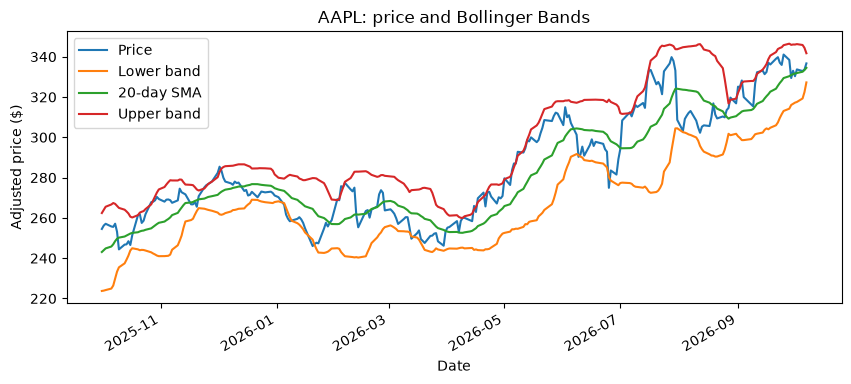

In [20]:
ticker = "AAPL"
band_chart = pd.DataFrame({
    "Price": prices[ticker],
    "Lower band": lower_band[ticker],
    "20-day SMA": middle_band[ticker],
    "Upper band": upper_band[ticker],
})
band_chart.loc[strategy_start:].plot(
    figsize=(10, 4), title=f"{ticker}: price and Bollinger Bands", ylabel="Adjusted price ($)"
)


Check the band ordering and the same net and gross exposures as before. Unlike RSI, %B can fall below zero or above one, so we do not check for a 0-to-1 range. The last return includes the unfinished month so far, valued at the latest available close. This date is used for valuation, not an early rebalance.

In [21]:
assert ((lower_band <= middle_band) | middle_band.isna()).all().all()
assert ((middle_band <= upper_band) | middle_band.isna()).all().all()
assert bb_monthly_weights.sum(axis=1).abs().lt(1e-10).all()
assert (bb_monthly_weights.abs().sum(axis=1) - 1).abs().lt(1e-10).all()

bb_monthly_returns.mul(100).to_frame(name="Return (%)").round(2).tail()


,Return (%)
2026-06-30,1.41
2026-07-31,2.89
2026-08-31,-1.34
2026-09-30,3.44
2026-10-07,-0.46


Compound the holding-period returns. As before, the result excludes trading costs, short borrowing fees, and cash interest.

In [22]:
bb_total_return = (1 + bb_monthly_returns).prod() - 1
print(f"Bollinger Bands mean-reversion portfolio return: {bb_total_return:.2%}")

Bollinger Bands mean-reversion portfolio return: 2.10%
